# Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.discriminant_analysis import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


# Understanding the Dataset

## Loading the Dataset

In [34]:
data = pd.read_csv("final_project_dataset_complete.csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   9000 non-null   float64
 1   feature_2   9000 non-null   float64
 2   feature_3   8600 non-null   float64
 3   feature_4   9000 non-null   float64
 4   feature_5   9000 non-null   float64
 5   feature_6   8500 non-null   float64
 6   feature_7   9000 non-null   float64
 7   feature_8   9000 non-null   float64
 8   category_1  9000 non-null   object 
 9   category_2  9000 non-null   object 
 10  target      9000 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 773.6+ KB


In [35]:
print("Shape:", data.shape)
display(data.head(5))

Shape: (9000, 11)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


In [36]:
print("\nSummary statistics (numeric):")
display(data.describe().T)
print("\nSummary statistics (all):")
display(data.describe(include='all').T)


Summary statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
feature_1,9000.0,0.000427,1.241318,-18.665400,-0.680062,-0.003938,0.680513,21.934496
feature_2,9000.0,0.003349,2.508324,-37.852816,-1.382610,-0.016698,1.380228,47.603454
feature_3,8600.0,0.003235,1.542901,-6.676680,-1.022085,0.005196,1.038571,6.203055
feature_4,9000.0,-0.008481,2.061784,-8.190124,-1.399928,-0.019541,1.394151,8.189001
feature_5,9000.0,-0.002177,0.577415,-0.999791,-0.502614,0.001695,0.497004,0.999914
feature_6,8500.0,-0.006447,1.981615,-8.590782,-1.329040,-0.003137,1.324897,6.803751
feature_7,9000.0,0.000592,1.075064,-4.422265,-0.700078,-0.000097,0.731942,3.857219
feature_8,9000.0,0.003348,2.043643,-9.474989,-1.356620,-0.007584,1.402024,7.572578
target,9000.0,0.475444,0.499424,0.000000,0.000000,0.000000,1.000000,1.000000



Summary statistics (all):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
feature_1,9000.0,NaN,NaN,NaN,0.000427,1.241318,-18.6654,-0.680062,-0.003938,0.680513,21.934496
feature_2,9000.0,NaN,NaN,NaN,0.003349,2.508324,-37.852816,-1.38261,-0.016698,1.380228,47.603454
feature_3,8600.0,NaN,NaN,NaN,0.003235,1.542901,-6.67668,-1.022085,0.005196,1.038571,6.203055
feature_4,9000.0,NaN,NaN,NaN,-0.008481,2.061784,-8.190124,-1.399928,-0.019541,1.394151,8.189001
feature_5,9000.0,NaN,NaN,NaN,-0.002177,0.577415,-0.999791,-0.502614,0.001695,0.497004,0.999914
feature_6,8500.0,NaN,NaN,NaN,-0.006447,1.981615,-8.590782,-1.32904,-0.003137,1.324897,6.803751
feature_7,9000.0,NaN,NaN,NaN,0.000592,1.075064,-4.422265,-0.700078,-0.000097,0.731942,3.857219
feature_8,9000.0,NaN,NaN,NaN,0.003348,2.043643,-9.474989,-1.35662,-0.007584,1.402024,7.572578
category_1,9000,4,Low,2802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_2,9000,3,Region B,3618,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
for col in ["category_1", "category_2"]:
    print(f"\nValue counts for {col}:")
    display(data[col].value_counts())


Value counts for category_1:


category_1
Low              2802
High             2763
Above Average    1727
Below Average    1708
Name: count, dtype: int64


Value counts for category_2:


category_2
Region B    3618
Region A    3551
Region C    1831
Name: count, dtype: int64

In [38]:
print("\nData types:")
print(data.dtypes)
print("\nMissing values per column:")
print(data.isna().sum())


Data types:
feature_1     float64
feature_2     float64
feature_3     float64
feature_4     float64
feature_5     float64
feature_6     float64
feature_7     float64
feature_8     float64
category_1     object
category_2     object
target          int64
dtype: object

Missing values per column:
feature_1       0
feature_2       0
feature_3     400
feature_4       0
feature_5       0
feature_6     500
feature_7       0
feature_8       0
category_1      0
category_2      0
target          0
dtype: int64


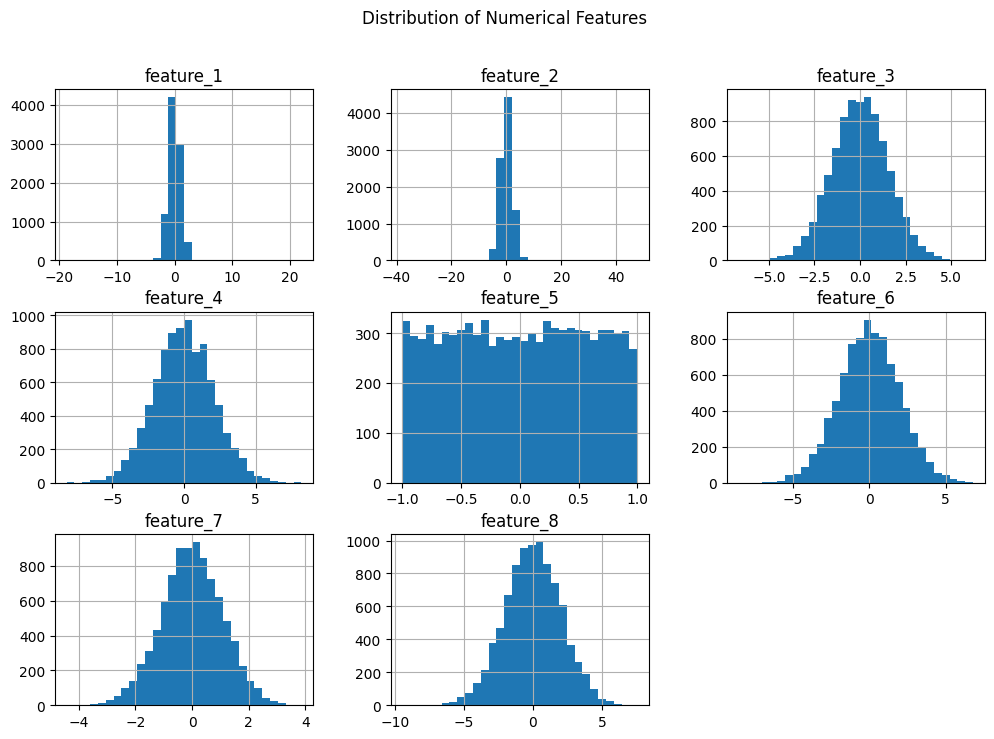

In [39]:
num_cols = [col for col in data.select_dtypes(include=np.number).columns.drop("target") if not col.startswith('category_')]

data[num_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

## Data Preprocessing

### Handelling missing values

In [40]:
print(data.isnull().sum())

imputer = SimpleImputer(missing_values=np.nan, strategy='median')
data['feature_3'] = imputer.fit_transform(data['feature_3'].values.reshape(-1, 1))
data['feature_6'] = imputer.fit_transform(data['feature_6'].values.reshape(-1, 1))

print("\nAfter replacing missing values:")
print("feature_3 missing value:",data['feature_3'].isnull().sum())
print("feature_6 missing value:",data['feature_6'].isnull().sum())

feature_1       0
feature_2       0
feature_3     400
feature_4       0
feature_5       0
feature_6     500
feature_7       0
feature_8       0
category_1      0
category_2      0
target          0
dtype: int64

After replacing missing values:
feature_3 missing value: 0
feature_6 missing value: 0


### Labelling the categorical features

In [41]:

cat_features = ['category_1', 'category_2']

# Label encoding for categorical feature
label_encoder = LabelEncoder()
for feature in cat_features:
    data[feature] = label_encoder.fit_transform(data[feature])

data.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,0,2,1
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,1,0,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,2,2,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,2,1,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,1,2,0


### Outlier

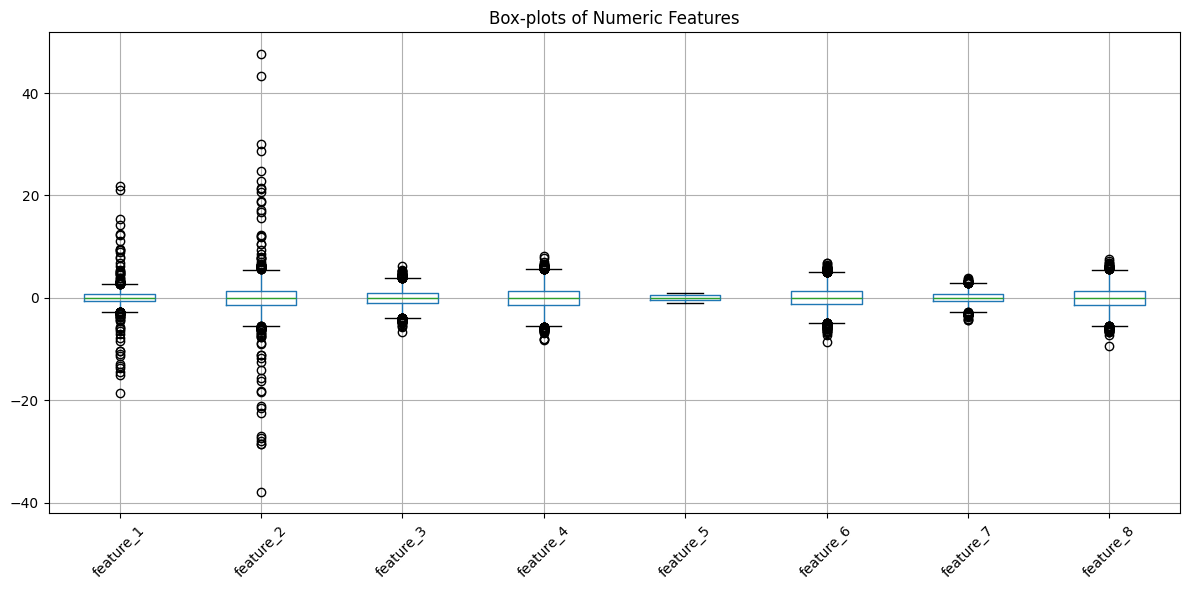

In [42]:




plt.figure(figsize=(12, 6))
data[num_cols].boxplot()
plt.title("Box-plots of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
def iqr_outliers(dataset,feature_name, multiplier=2):
    
    Q1 = dataset[feature_name].quantile(0.25)
    Q3 = dataset[feature_name].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lwr_bound = Q1 - multiplier * IQR
    upp_bound = Q3 + multiplier * IQR 
    
    ls = dataset.index[np.logical_or(dataset[feature_name]<lwr_bound, 
                                dataset[feature_name]>upp_bound)] 
    return ls #return the indexes

outliers_detected={}
for i in num_cols:
    outliers = iqr_outliers(data,i)
    outliers_detected[i] = outliers
    
    print('Variable',i)
    print(outliers)
    print(data[i].iloc[outliers])
    print('\n')

Variable feature_1
Index([ 209,  277,  469,  496,  598,  774, 1400, 1445, 1785, 2093, 2218, 2228,
       2336, 2442, 2458, 2895, 3227, 3245, 3336, 3510, 3569, 3872, 3986, 4026,
       4029, 4091, 4265, 4359, 4531, 5316, 5416, 5488, 5649, 5773, 5935, 5998,
       6408, 6628, 6693, 6747, 6891, 7060, 7178, 7611, 7677, 7839, 8067, 8200,
       8354, 8630, 8714],
      dtype='int64')
209      3.852731
277     -6.002169
469     -5.758182
496    -10.372462
598     -4.442933
774      6.218100
1400   -10.469110
1445    -6.513569
1785   -14.575515
2093   -11.388331
2218    20.997218
2228   -18.665400
2336     5.006657
2442   -12.922627
2458     4.996851
2895     3.926238
3227    12.496189
3245     7.719202
3336   -13.658242
3510    12.208213
3569     9.040176
3872   -10.973683
3986     5.531492
4026    -7.811564
4029     8.021285
4091    14.205043
4265     4.935602
4359     6.802204
4531     9.452115
5316   -15.100412
5416    -3.824524
5488    -7.114622
5649     9.386400
5773    -8.360917
5935  

In [44]:
for i in num_cols:
    data[i] = data[i].replace(data[i].iloc[outliers_detected[i]].values,data[i].median())

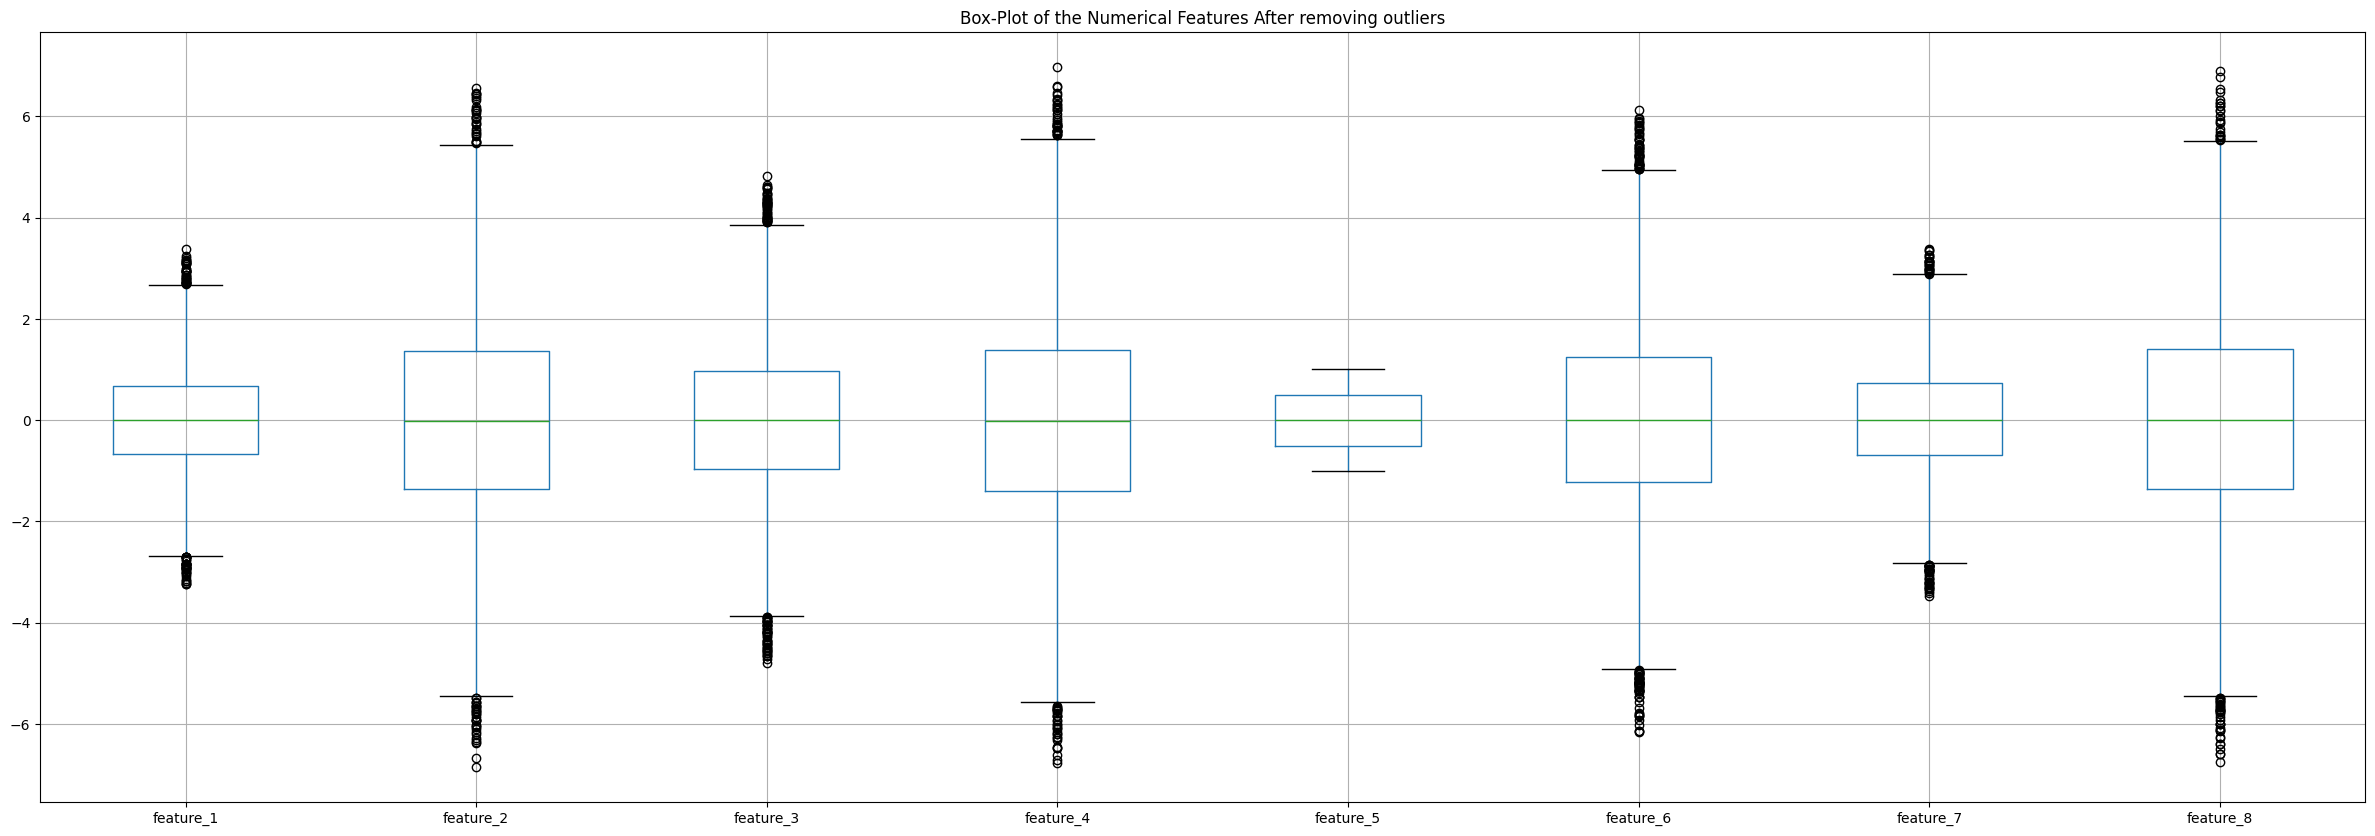

In [45]:
plt.figure(figsize=(30, 10))
plt.title('Box-Plot of the Numerical Features After removing outliers')
data[num_cols].boxplot(grid=True)
plt.show()

# EDA

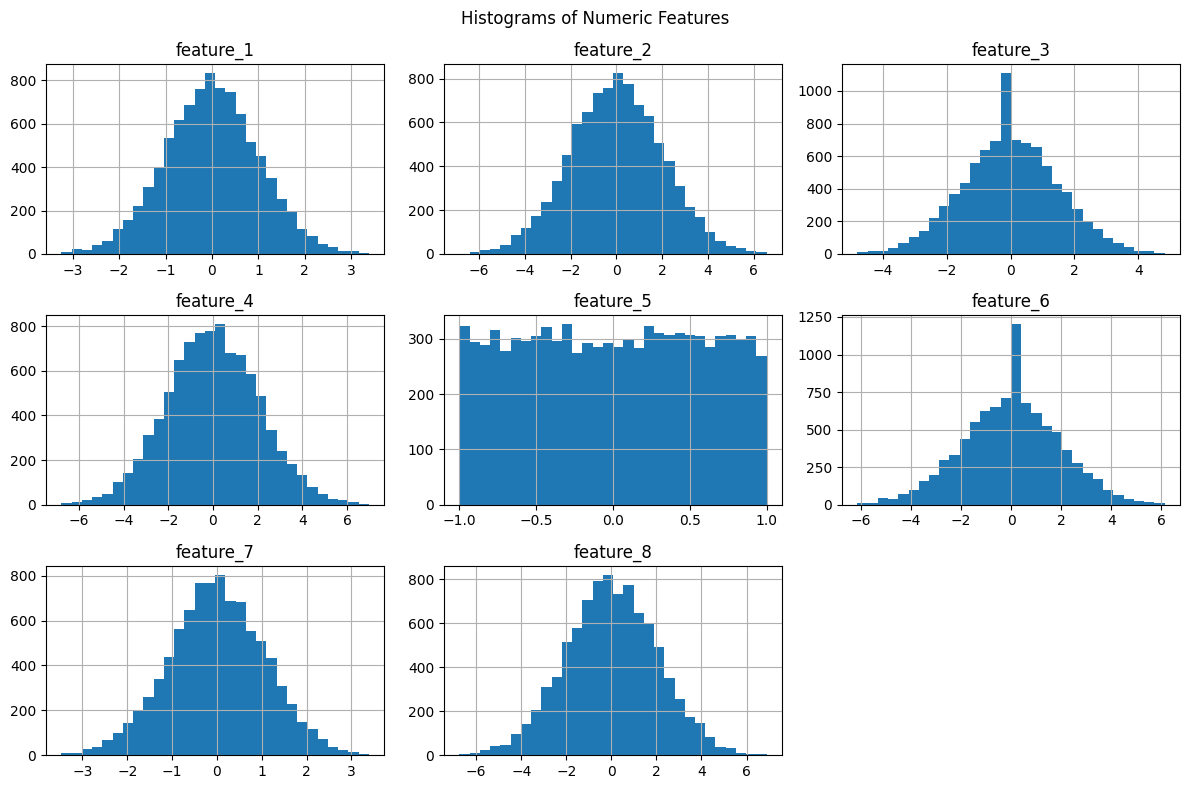

In [46]:

data[num_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

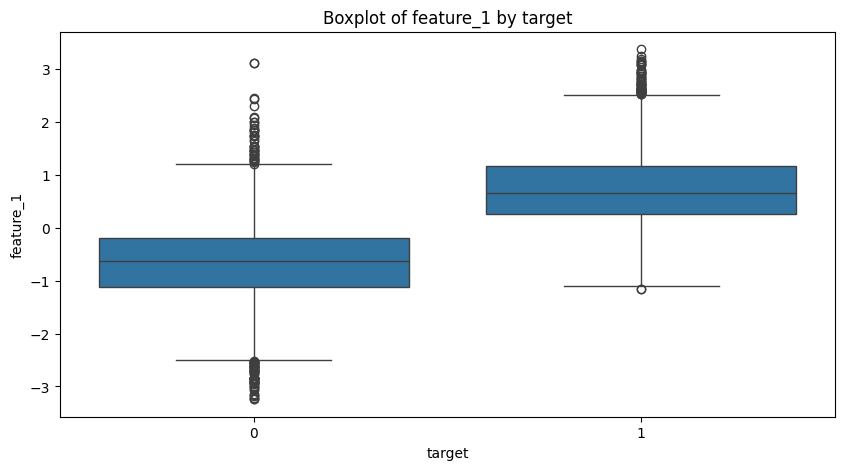

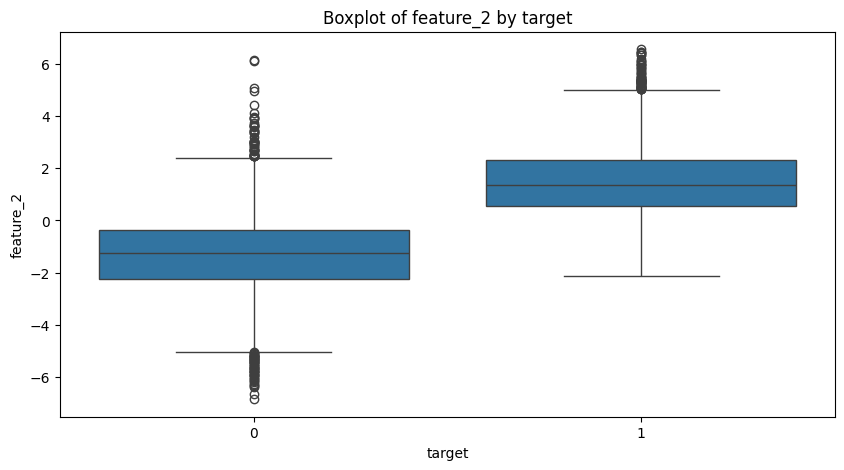

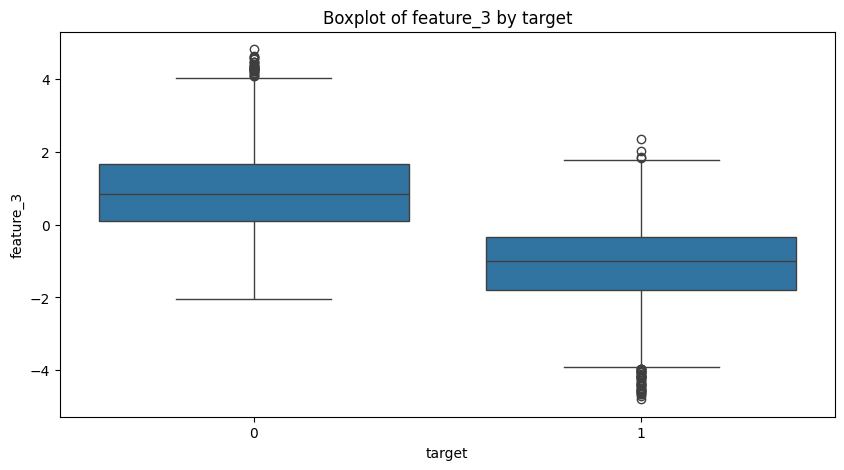

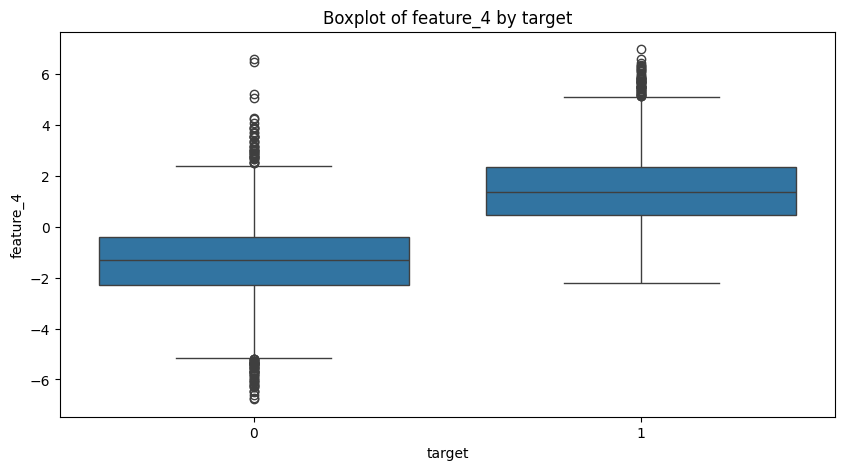

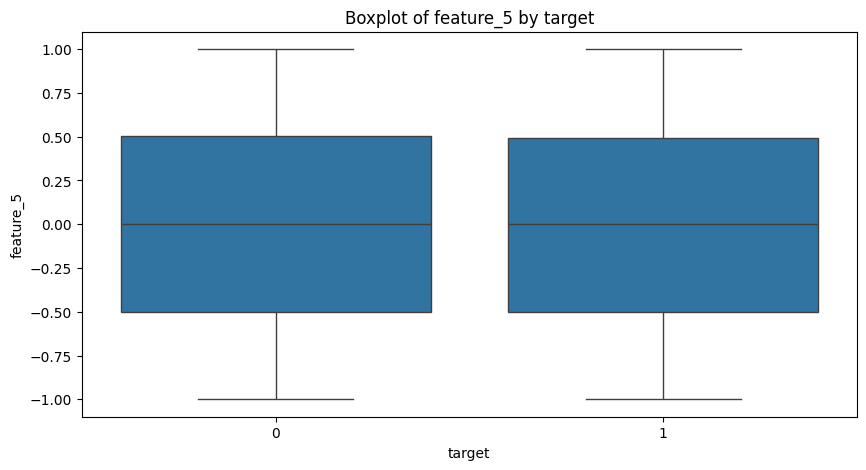

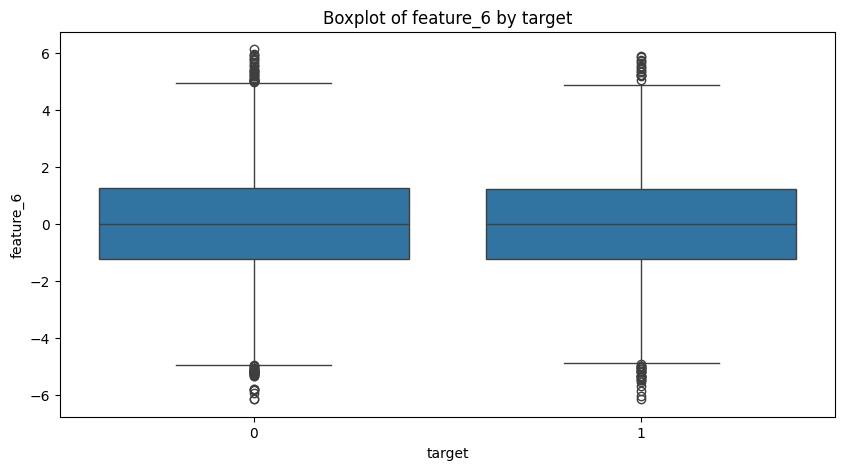

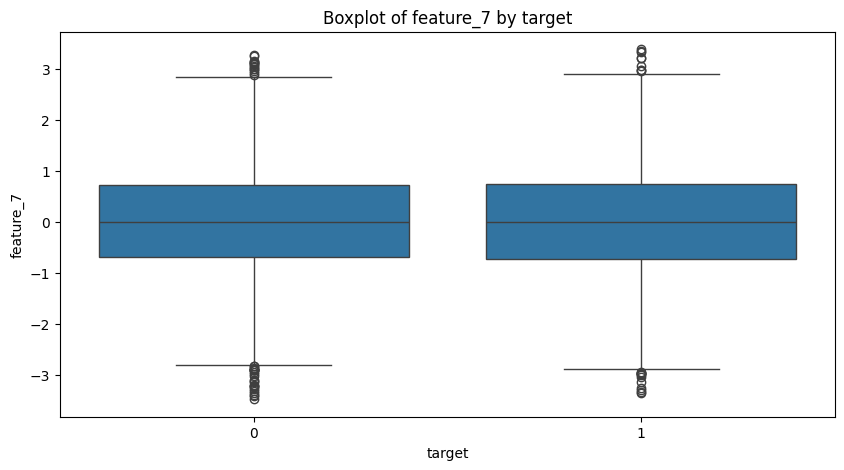

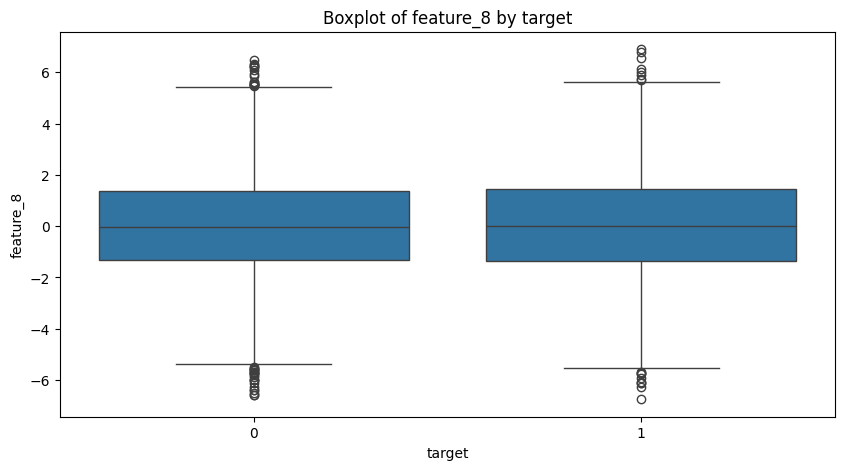

In [47]:
# Investigate relationships between features and the target variable
for column in num_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='target', y=column, data=data)
    plt.title(f'Boxplot of {column} by target')
    plt.show()

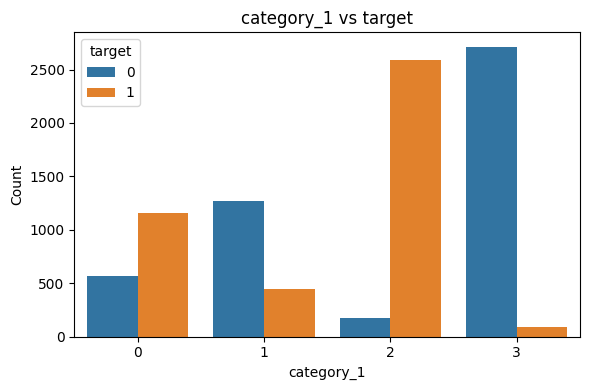

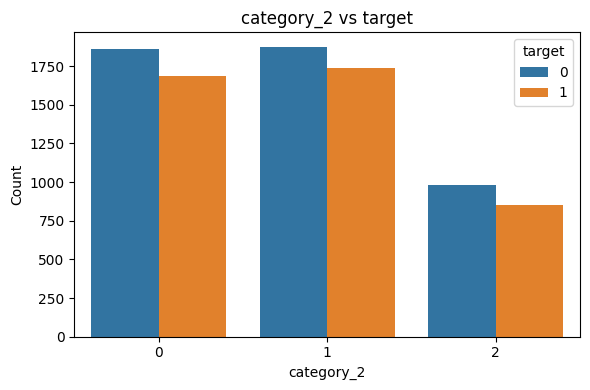

In [48]:

cat_cols  = ["category_1", "category_2"]  # edit as needed
target    = "target"

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x=col, hue=target)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title=target)
    plt.tight_layout()
    plt.show()

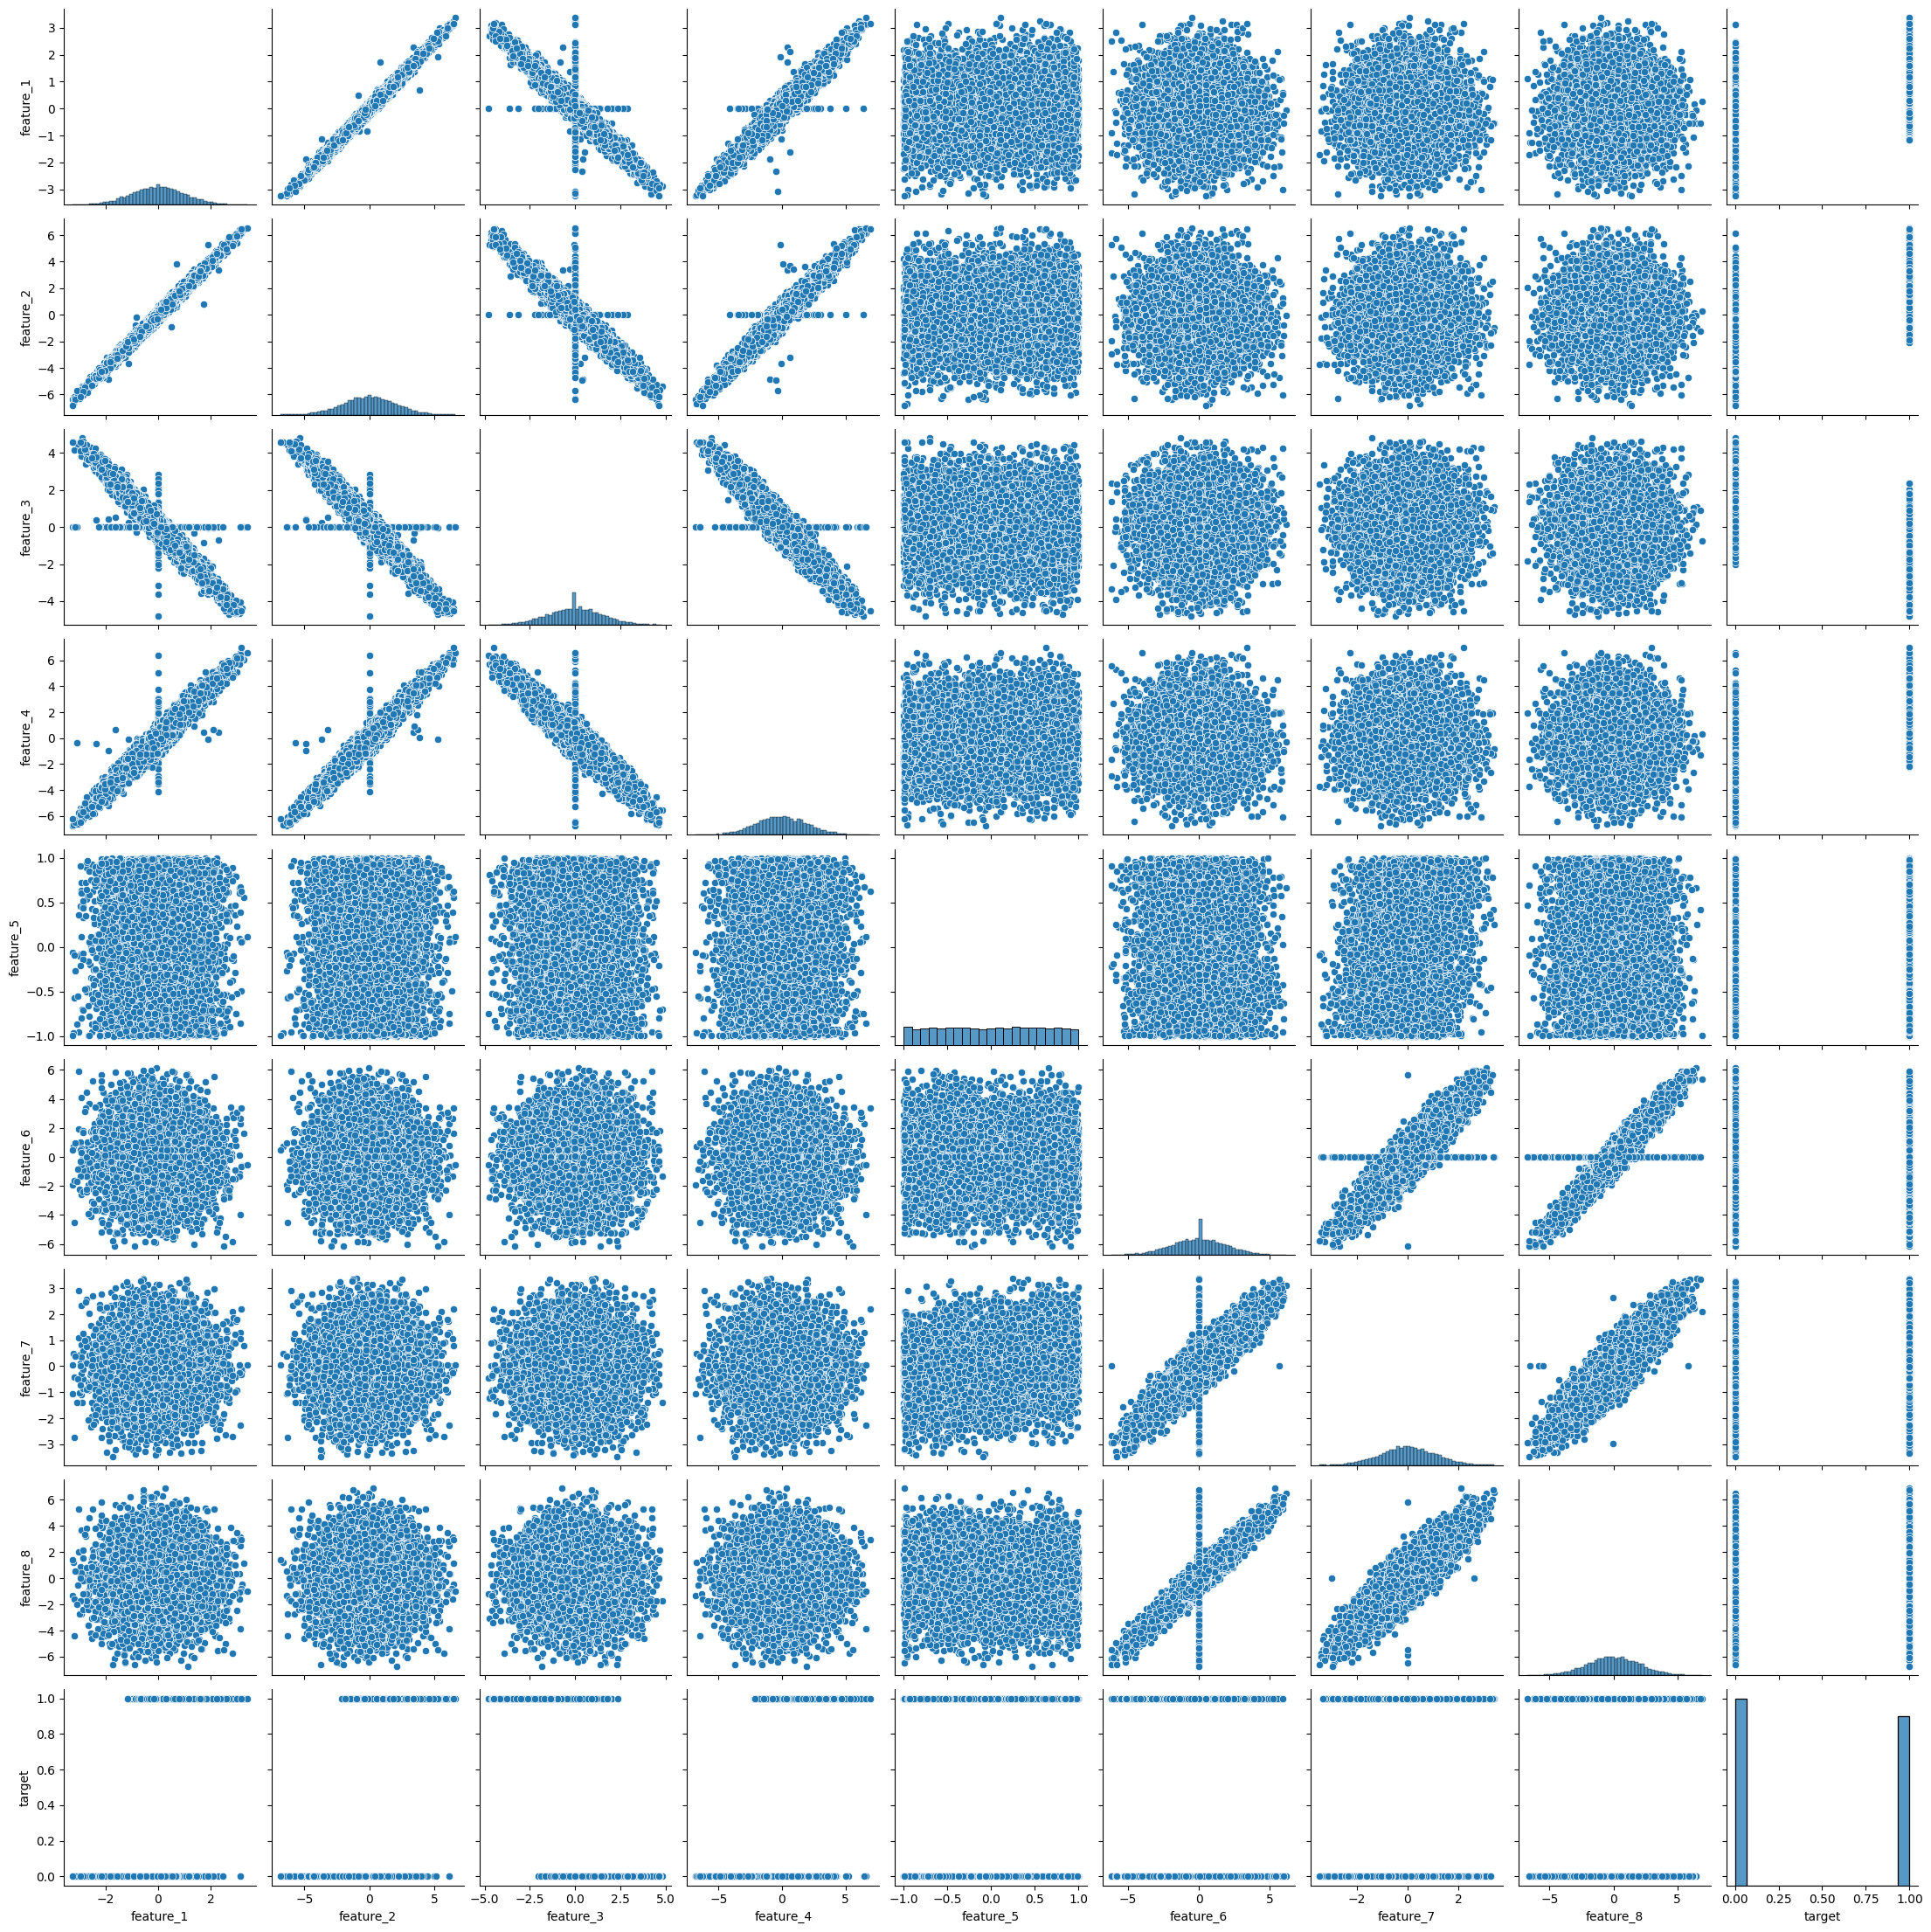

In [49]:
sns.pairplot(data[num_cols + ['target']])
plt.show()

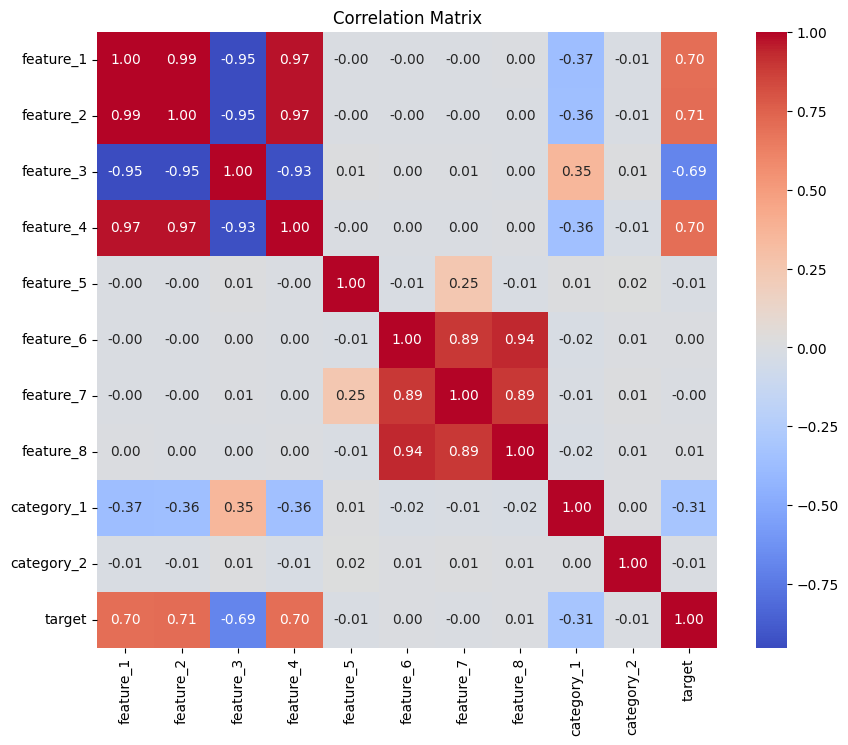

In [50]:
correlation_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Hypothesis Testing

### T-test

In [51]:
results = {}

for feature in num_cols:
    group1 = data[data['target'] == 1][feature].dropna()
    group0 = data[data['target'] == 0][feature].dropna()
    
    # ▼ swap group0, group1  +  unequal‑variance test
    t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=False)
    
    results[feature] = {'t_statistic': t_stat, 'p_value': p_value}
    

results_df = pd.DataFrame(results).T
results_df.index.name = 'Feature'
print(results_df.round({'t_statistic': 4, 'p_value': 4}))



           t_statistic  p_value
Feature                        
feature_1     -93.7834   0.0000
feature_2     -94.7038   0.0000
feature_3      90.5290   0.0000
feature_4     -92.1744   0.0000
feature_5       0.7471   0.4550
feature_6      -0.1600   0.8729
feature_7       0.1163   0.9074
feature_8      -0.6072   0.5437


### Chi-square testing

In [52]:
chi_square_results = {}

for col in ["category_1", "category_2"]:
    contingency = pd.crosstab(data[col], data["target"])
    chi2, p, dof, exp = stats.chi2_contingency(contingency)
    chi_square_results[col] = {"chi2_statistic": chi2,
                               "p_value": p}

chi_df = (pd.DataFrame(chi_square_results)
          .T
          .round({"chi2_statistic": 4, "p_value": 4})
          .rename_axis("Category"))

print(chi_df)

            chi2_statistic  p_value
Category                           
category_1       5175.3203    0.000
category_2          1.3193    0.517


In [53]:
data.to_csv("cleaned.csv")

# Feature Engineering

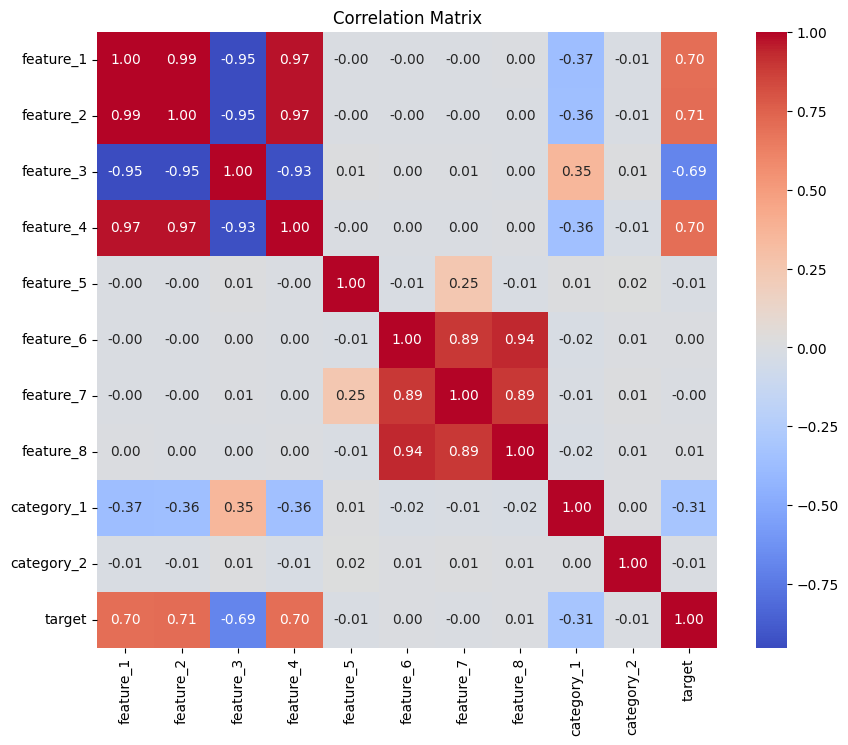

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

            feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
feature_1    0.000000   0.994744  -0.951298   0.970045  -0.003846  -0.000649   
feature_2    0.994744   0.000000  -0.946155   0.974608  -0.003097  -0.001133   
feature_3   -0.951298  -0.946155   0.000000  -0.933385   0.010417   0.003238   
feature_4    0.970045   0.974608  -0.933385   0.000000  -0.002090   0.001142   
feature_5   -0.003846  -0.003097   0.010417  -0.002090   0.000000  -0.010682   
feature_6   -0.000649  -0.001133   0.003238   0.001142  -0.010682   0.000000   
feature_7   -0.000517  -0.000880   0.005444   0.000803   0.250729   0.889956   
feature_8    0.002105   0.001477   0.000343   0.002977  -0.013275   0.935628   
category_1  -0.365574  -0.363115   0.352298  -0.355511   0.010906  -0.017328   
category_2  -0.011992  -0.013186   0.013816  -0.014174   0.018556   0.006360   
target       0.701747   0.705193  -0.690683   0.695689  -0.007873   0.001684   

            feature_7  feature_8  categ

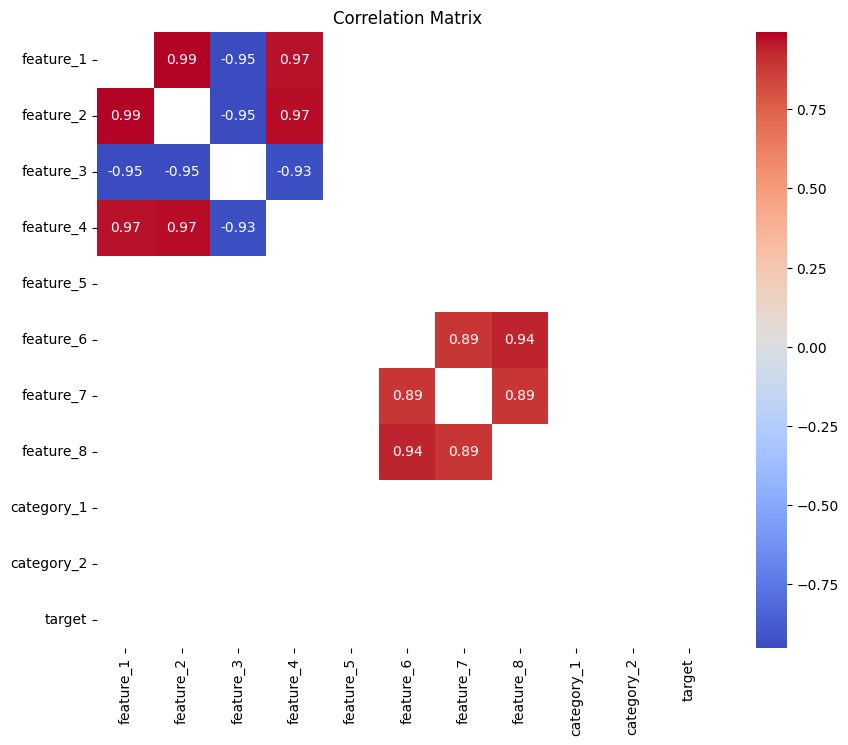

In [55]:
np.fill_diagonal(correlation_matrix.values,val=0)
print(correlation_matrix)

neg_threshold = -0.8
pos_threshold = 0.8
correlation_hc_matrix = correlation_matrix[(correlation_matrix>=pos_threshold) | (correlation_matrix<=neg_threshold)] 

# Visualize Correlation Matrix for highly correlated features
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_hc_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [56]:
# Feature 3 is negatively correlated with the others.

data["feature_3_inv"]   = -data["feature_3"]
data["cluster1_2_3_4"]   = data[["feature_1","feature_2","feature_4","feature_3_inv"]].mean(axis=1)

# Cluster 2: features 6, 7, and 8
data["cluster6_7_8"]    = data[["feature_6", "feature_7", "feature_8"]].mean(axis=1)

# dropped the originals 
to_drop = ["feature_1","feature_2","feature_3","feature_4",
           "feature_6","feature_7","feature_8","feature_3_inv"]
data = data.drop(columns=to_drop)


print(data.head())

   feature_5  category_1  category_2  target  cluster1_2_3_4  cluster6_7_8
0   0.784920           0           2       1        0.781187     -1.917261
1   0.704674           1           0       0        0.049615     -1.926697
2  -0.250029           2           2       1        1.128799      1.550019
3   0.882201           2           1       1        2.322824      2.991862
4   0.610601           1           2       0       -0.437824      0.248574


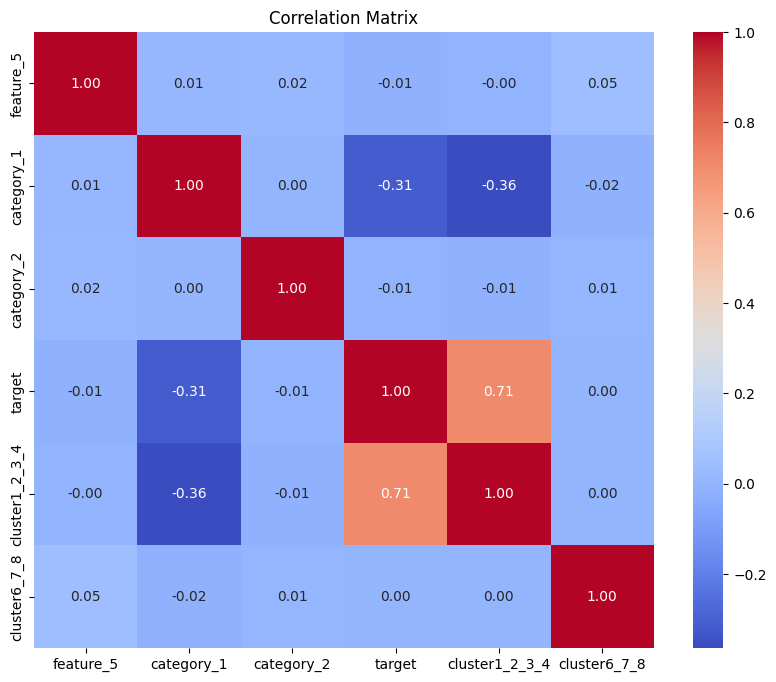

In [57]:
correlation_fet_eng = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_fet_eng, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Modeling

## Data preparation and feature selection

In [58]:
X = data.drop('target', axis=1)
y = data['target']

In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)

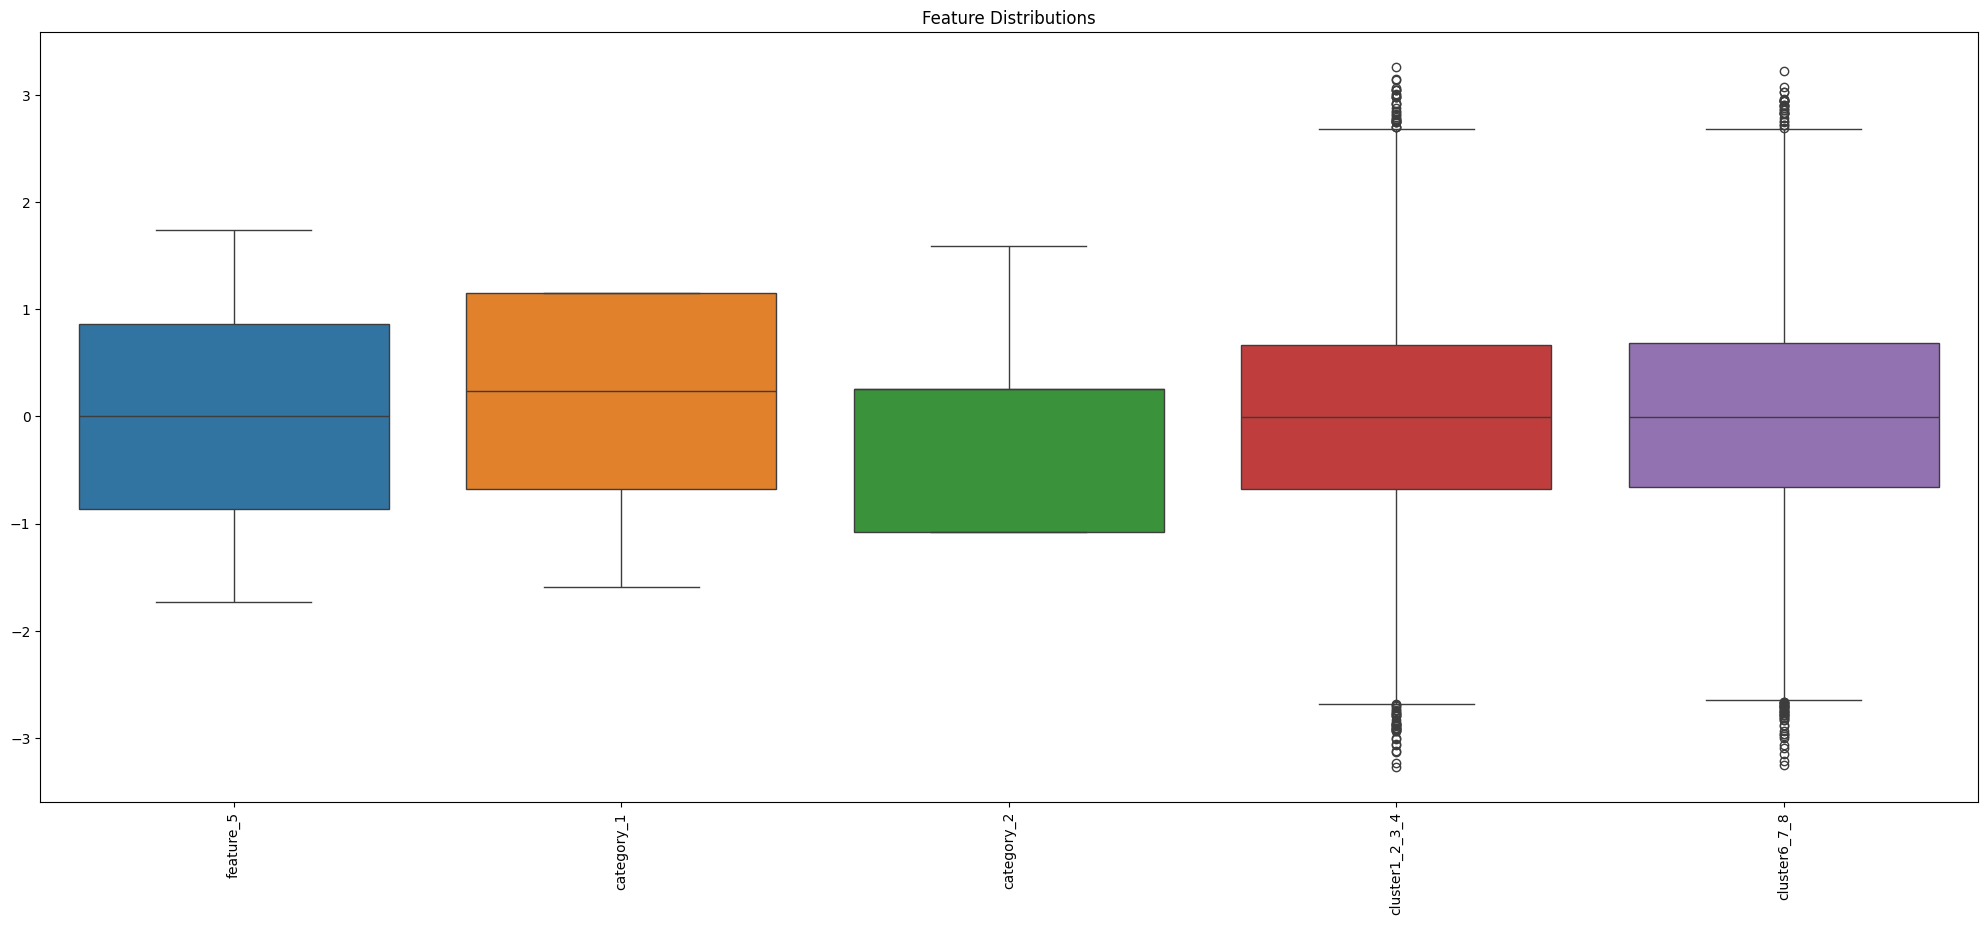

In [60]:
plt.figure(figsize=(25, 10))
sns.boxplot(data=X_scaled)
plt.title('Feature Distributions')
plt.xticks(rotation=90)
plt.show()

In [61]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [62]:
print("Class Distribution in training set:\n", y_train.value_counts())
print("Class Distribution in testing set:\n", y_test.value_counts())

Class Distribution in training set:
 target
0    3314
1    2986
Name: count, dtype: int64
Class Distribution in testing set:
 target
0    1407
1    1293
Name: count, dtype: int64


In [63]:
X_train.to_csv('X_train_data.csv')
y_train.to_csv('y_train_data.csv')
X_test.to_csv('X_test_data.csv')
y_test.to_csv('y_test_data.csv')

# Model Evaluation


In [64]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train)
    # Predictions
    predictions = model.predict(X_test)
    
    print("Classification Report:")
    print(classification_report(y_test, predictions))

    # Evaluation
    conf_matrix = confusion_matrix(y_test, predictions)

    # Visualization of Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu", fmt='g')
    plt.title('Confusion matrix')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

    return model

In [65]:
def evaluate_model_hypertunning(model, param_grid, X_train, y_train, X_test, y_test):
    # GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    # Training the model with the best parameters
    best_model = grid_search.best_estimator_

    # Predictions
    predictions = best_model.predict(X_test)

    # Best parameters
    best_parameters = grid_search.best_params_
    print("Best Parameters:", best_parameters)
    
    print("Classification Report:")
    print(classification_report(y_test, predictions))

    # Evaluation
    conf_matrix = confusion_matrix(y_test, predictions)

    # Visualization of Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu", fmt='g')
    plt.title('Confusion matrix')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

    return best_model

In [66]:
# Check overfitting
def check_overfitting(model, X_train, y_train, X_test, y_test):
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")

In [67]:
def feature_importance(model, selected_features):
    # Feature importances from Best Random Forest
    importances = model.feature_importances_
    feature_names = X[selected_features].columns
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    print(feature_importance_df.sort_values(by='importance', ascending=False))

## Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1407
           1       0.85      0.81      0.83      1293

    accuracy                           0.84      2700
   macro avg       0.84      0.84      0.84      2700
weighted avg       0.84      0.84      0.84      2700



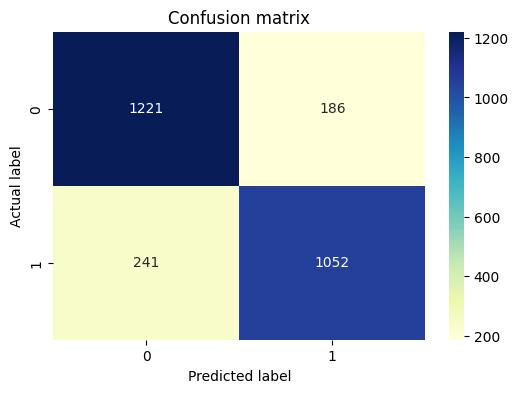

Training Accuracy: 1.0000
Testing Accuracy: 0.8419
          feature  importance
3  cluster1_2_3_4    0.531095
1      category_1    0.192276
4    cluster6_7_8    0.128982
0       feature_5    0.128921
2      category_2    0.018726


In [68]:
RF_model = RandomForestClassifier(random_state=42)

rf = evaluate_model(RF_model, X_train, y_train, X_test, y_test)
check_overfitting(rf, X_train, y_train, X_test, y_test)
feature_importance(rf, X.columns)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1407
           1       0.86      0.85      0.85      1293

    accuracy                           0.86      2700
   macro avg       0.86      0.86      0.86      2700
weighted avg       0.86      0.86      0.86      2700



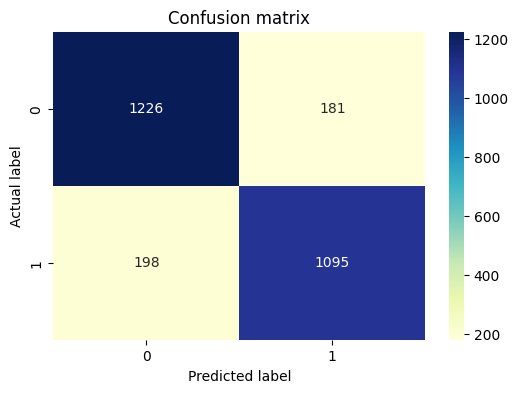

Training Accuracy: 0.8900
Testing Accuracy: 0.8596
          feature  importance
3  cluster1_2_3_4    0.616586
1      category_1    0.271061
0       feature_5    0.052341
4    cluster6_7_8    0.051907
2      category_2    0.008105


In [69]:
# Example usage for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200], 
    'max_depth': [None, 10, 20, 30], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
}
rf_hyper = evaluate_model_hypertunning(RandomForestClassifier(random_state=42), rf_param_grid, X_train, y_train, X_test, y_test)
check_overfitting(rf_hyper, X_train, y_train, X_test, y_test)
feature_importance(rf_hyper, X.columns)



## Decision Tree


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1407
           1       0.79      0.77      0.78      1293

    accuracy                           0.79      2700
   macro avg       0.79      0.79      0.79      2700
weighted avg       0.79      0.79      0.79      2700



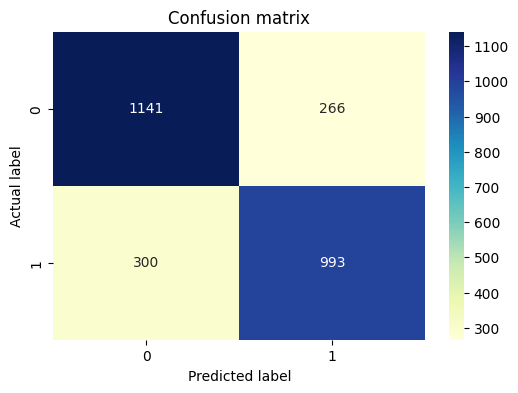

Training Accuracy: 1.0000
Testing Accuracy: 0.7904
          feature  importance
3  cluster1_2_3_4    0.723654
4    cluster6_7_8    0.124139
0       feature_5    0.119614
2      category_2    0.025567
1      category_1    0.007027


In [70]:
DT_model = DecisionTreeClassifier(random_state=42)

# usage for Decision Tree
dt = evaluate_model(DT_model, X_train, y_train, X_test, y_test)
check_overfitting(dt, X_train, y_train, X_test, y_test)
feature_importance(dt, X.columns)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1407
           1       0.83      0.83      0.83      1293

    accuracy                           0.84      2700
   macro avg       0.84      0.84      0.84      2700
weighted avg       0.84      0.84      0.84      2700



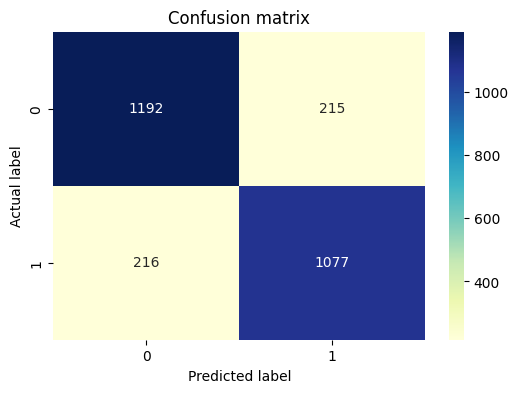

Training Accuracy: 0.8979
Testing Accuracy: 0.8404
          feature  importance
3  cluster1_2_3_4    0.886999
4    cluster6_7_8    0.055637
0       feature_5    0.044588
2      category_2    0.008269
1      category_1    0.004507


In [71]:
# usage for Decision Tree
dt_param_grid = {
    'max_depth': [None, 10, 20, 30], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
}
dt_hyper = evaluate_model_hypertunning(DT_model, dt_param_grid, X_train, y_train, X_test, y_test)
check_overfitting(dt_hyper, X_train, y_train, X_test, y_test)
feature_importance(dt_hyper, X.columns)

## Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1407
           1       0.86      0.85      0.86      1293

    accuracy                           0.86      2700
   macro avg       0.86      0.86      0.86      2700
weighted avg       0.86      0.86      0.86      2700



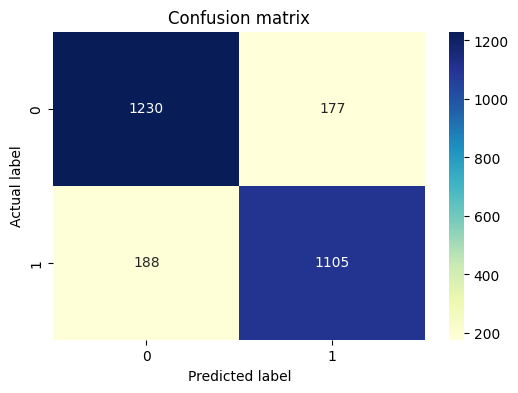

Training Accuracy: 0.8579
Testing Accuracy: 0.8648


In [72]:
LR_model = LogisticRegression(random_state=42, max_iter=1000)

# usage for Logistic Regression
lr = evaluate_model(LR_model, X_train, y_train, X_test, y_test)
check_overfitting(lr, X_train, y_train, X_test, y_test)


Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1407
           1       0.85      0.86      0.85      1293

    accuracy                           0.86      2700
   macro avg       0.86      0.86      0.86      2700
weighted avg       0.86      0.86      0.86      2700



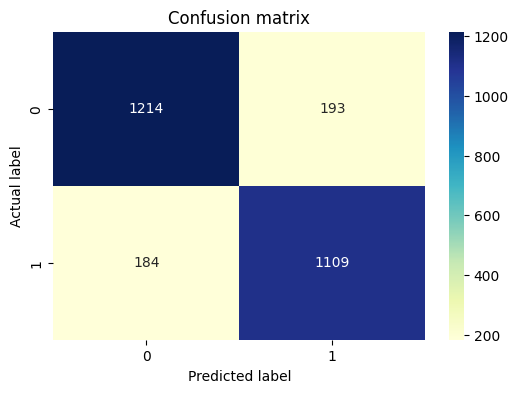

Training Accuracy: 0.8589
Testing Accuracy: 0.8604


In [73]:
# usage for Logistic Regression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
lr_hyper = evaluate_model_hypertunning(LogisticRegression(random_state=42, max_iter=1000), lr_param_grid, X_train, y_train, X_test, y_test)
check_overfitting(lr_hyper, X_train, y_train, X_test, y_test)


## Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1407
           1       0.86      0.85      0.86      1293

    accuracy                           0.86      2700
   macro avg       0.86      0.86      0.86      2700
weighted avg       0.86      0.86      0.86      2700



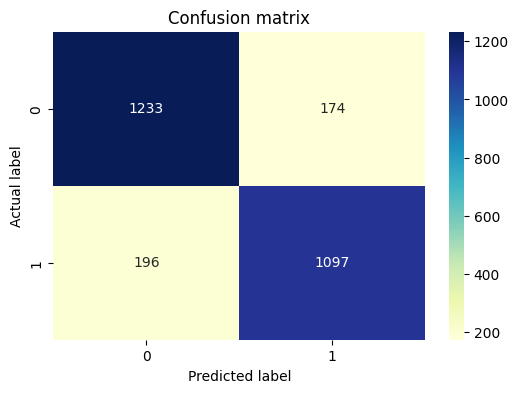

Training Accuracy: 0.8702
Testing Accuracy: 0.8630
          feature  importance
3  cluster1_2_3_4    0.975856
0       feature_5    0.009889
4    cluster6_7_8    0.007849
1      category_1    0.005876
2      category_2    0.000529


In [74]:
GB_model = GradientBoostingClassifier(random_state=42)

# Example usage for Gradient Boosting
gb = evaluate_model(GB_model, X_train, y_train, X_test, y_test)
check_overfitting(gb, X_train, y_train, X_test, y_test)
feature_importance(gb, X.columns)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1407
           1       0.87      0.83      0.85      1293

    accuracy                           0.86      2700
   macro avg       0.86      0.86      0.86      2700
weighted avg       0.86      0.86      0.86      2700



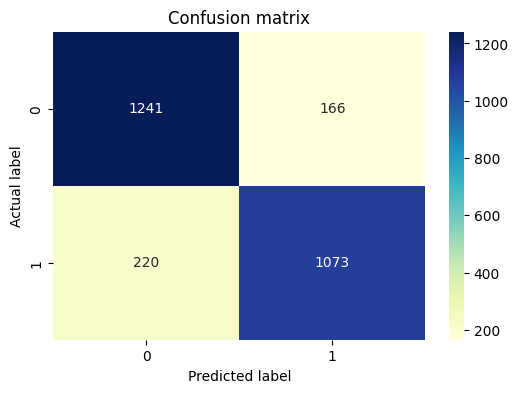

Training Accuracy: 0.8621
Testing Accuracy: 0.8570
          feature  importance
3  cluster1_2_3_4    0.988065
4    cluster6_7_8    0.005490
1      category_1    0.003974
0       feature_5    0.002465
2      category_2    0.000006


In [75]:
# Example usage for Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 200], 
    'learning_rate': [0.01, 0.1, 0.2], 
    'max_depth': [3, 4, 5], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4]
}
gb_hyper = evaluate_model_hypertunning(GB_model, gb_param_grid, X_train, y_train, X_test, y_test)
check_overfitting(gb_hyper, X_train, y_train, X_test, y_test)
feature_importance(gb_hyper, X.columns)


